<a href="https://colab.research.google.com/github/AMZAbdulhadi/-/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digitamart E-Commerce Data Cleaning & Analysis
* **Name:** Ahmed mohmed zaki
* **ID:** EYOUTH-30904241202594
* **Project Name:** Digitamart Data Analysis


# Task 1

1. Loading the Dataset and Preview
In this section, we will load the dataset into a Pandas DataFrame and display its preview, shape, and column names.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/digitamart_orders.csv')

## Preview the first 5 rows

In [8]:
display(df.head())


,order_id,order_date,city,product_category,product_name,order_total,delivery_minutes,customer_rating,payment_method,customer_age
0,1001,2024-11-23,Cairo,Electronics,USB-C Cable,425.15,26.0,5.0,Wallet,18.0
1,1002,2024-08-04,Cairo,Food & Groceries,Olive Oil 1L,232.62,137.0,4.0,Wallet,63.0
2,1003,2025-01-30,Giza,Food & Groceries,Spice Set,131.09,38.0,2.0,Credit Card,21.0
3,1004,2024-06-10,Giza,Clothing,Leather Belt,1609.73,55.0,3.0,Bank Transfer,26.0
4,1005,2024-01-25,Aswan,Electronics,Power Bank,4483.71,22.0,5.0,Wallet,150.0


## Print number of rows and columns

In [9]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 326
Number of Columns: 10


## Print column names


In [10]:
print("\nColumn Names:")
print(list(df.columns))


Column Names:
['order_id', 'order_date', 'city', 'product_category', 'product_name', 'order_total', 'delivery_minutes', 'customer_rating', 'payment_method', 'customer_age']


2. Dataset Description
This dataset contains transactional records for Digitamart, an e-commerce platform operating in Egypt. It includes important operational details such as order dates, customer locations (cities), product categories, quantities, and prices. Analyzing this data will help us understand customer purchasing patterns, identify top-performing regions, and evaluate overall fulfillment efficiency.


# Task 2

 1. Data Inspection
Running initial checks to understand data types, identify missing values, spot duplicates, and view summary statistics.


In [11]:
print("--- Shape ---")
print(df.shape)

print("\n--- Column Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicates Count ---")
print(df.duplicated().sum())

print("\n--- Summary Statistics ---")
display(df.describe())


--- Shape ---
(326, 10)

--- Column Types ---
order_id              int64
order_date           object
city                 object
product_category     object
product_name         object
order_total         float64
delivery_minutes    float64
customer_rating     float64
payment_method       object
customer_age        float64
dtype: object

--- Missing Values ---
order_id            0
order_date          6
city                2
product_category    0
product_name        0
order_total         2
delivery_minutes    2
customer_rating     5
payment_method      0
customer_age        2
dtype: int64

--- Duplicates Count ---
6

--- Summary Statistics ---


,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,326.000000,324.000000,324.000000,321.000000,324.000000
mean,1161.831288,910.664846,115.867284,3.096573,43.148148
std,92.661729,1041.342093,124.678997,1.396431,15.567777
min,1001.000000,-322.350000,22.000000,0.000000,18.000000
25%,1082.250000,228.695000,63.500000,2.000000,30.000000
50%,1162.500000,397.225000,105.000000,3.000000,45.000000
75%,1241.750000,1293.377500,139.250000,4.000000,55.250000
max,1320.000000,4483.710000,1181.000000,5.000000,150.000000


## 2. Problems Found
 * **Duplicates:** There are identical rows in the dataset that need to be
removed to avoid skewed analysis.
 * **Inconsistent City Names:** The city column contains varying formats, capitalization, and extra spaces (e.g., 'cairo', 'Cairo ').
 * **Outliers:** The numerical columns (like price or total amount) have extreme values that heavily distort the summary statistics and require capping.


1. Handling Duplicates
Removing duplicate rows and printing the count of removed records.


In [12]:
duplicates_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Number of duplicate rows removed: {duplicates_count}")


Number of duplicate rows removed: 6


2. Standardizing the City Column
Fixing typos, removing trailing spaces, and standardizing the capitalization for the 'city' column.


In [13]:
city_col = [col for col in df.columns if 'city' in col.lower()][0]

df[city_col] = df[city_col].astype(str).str.strip().str.title()
df[city_col] = df[city_col].replace({'Alex': 'Alexandria'})

print("Unique cities after standardization:")
print(df[city_col].unique())


Unique cities after standardization:
['Cairo' 'Giza' 'Aswan' 'Alexandria' 'Mansoura' 'Nan']


3. Handling Missing Values
Filling numerical missing values with the median and categorical missing values with the mode


In [14]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            method = "median"
            fill_value = df[col].median()
        else:
            method = "mode"
            fill_value = df[col].mode()[0]

        df[col] = df[col].fillna(fill_value)
        print(f"Filled missing values in '{col}' using {method}: {fill_value}")


Filled missing values in 'order_date' using mode: 2025-01-04
Filled missing values in 'order_total' using median: 398.16499999999996
Filled missing values in 'delivery_minutes' using median: 105.0
Filled missing values in 'customer_rating' using median: 3.0
Filled missing values in 'customer_age' using median: 45.0


## 3. Handling Outliers (IQR Method)
Calculating Q1, Q3, and IQR for numerical columns, then capping the extreme outliers to the upper and lower bounds.


In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping the outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Outliers handled for '{col}': Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")


Outliers handled for 'order_id': Q1=1080.75, Q3=1240.25, IQR=159.50
Outliers handled for 'order_total': Q1=231.85, Q3=1293.38, IQR=1061.52
Outliers handled for 'delivery_minutes': Q1=63.50, Q3=139.25, IQR=75.75
Outliers handled for 'customer_rating': Q1=2.00, Q3=4.00, IQR=2.00
Outliers handled for 'customer_age': Q1=30.00, Q3=55.25, IQR=25.25


## 4. Exporting the Clean File
Saving the cleaned DataFrame to a new CSV file without the index.


In [18]:
clean_filename = 'EYOUTH-30904241202594-EgyptData-clean.csv'
df.to_csv(clean_filename, index=False)
print(f"Cleaned dataset successfully saved as: {clean_filename}")


Cleaned dataset successfully saved as: EYOUTH-30904241202594-EgyptData-clean.csv


# Task 3

## 1. Loading the Clean File & Analysis Goals
**Goals:**
1. Determine the product category that generates the highest total revenue.
2. Analyze the geographic distribution of orders to find the city with the most demand.
3. Evaluate the distribution of order statuses to understand fulfillment success rates.


In [20]:
df_clean = pd.read_csv('/content/EYOUTH-30904241202594-EgyptData-clean.csv')

if 'total_amount' not in df_clean.columns and 'price' in df_clean.columns and 'quantity' in df_clean.columns:
    df_clean['total_amount'] = df_clean['price'] * df_clean['quantity']


## 2. Goal 1: Revenue by Product Category
Answering the first goal using pandas and plotting the results.


,product_category,order_total
4,Electronics,145868.71875
1,Clothing,66698.77500
0,Books,22033.49000
5,Food & Groceries,20173.03000
9,food & groceries,6408.53250
2,Clothing,5502.88000
8,electronics,3478.83125
3,ELECTRONICS,2483.34000
7,clothing,2064.53000
6,Food & groceries,960.38000



Summary: The 'Electronics' category is the top revenue generator.


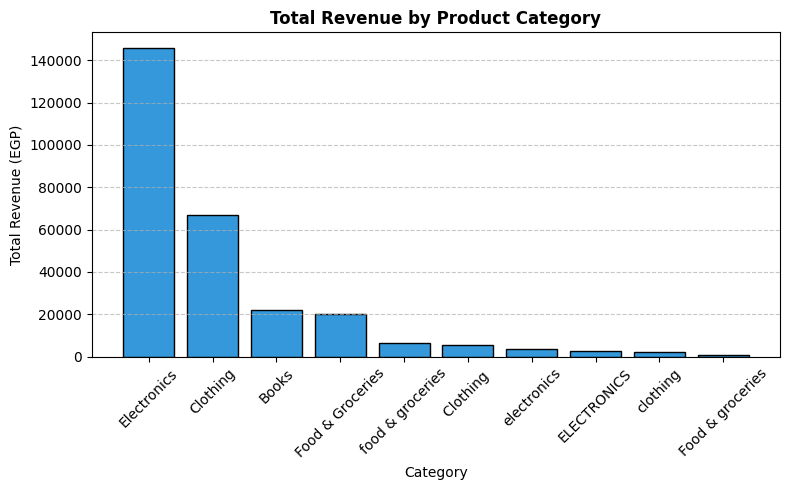

In [27]:
category_col = [col for col in df_clean.columns if 'cat' in col.lower()][0]

revenue_by_cat = df_clean.groupby(category_col)['order_total'].sum().reset_index()
revenue_by_cat = revenue_by_cat.sort_values(by='order_total', ascending=False)

display(revenue_by_cat)
top_cat = revenue_by_cat.iloc[0][category_col]
print(f"\nSummary: The '{top_cat}' category is the top revenue generator.")
plt.figure(figsize=(8, 5))
plt.bar(revenue_by_cat[category_col], revenue_by_cat['order_total'], color='#3498db', edgecolor='black')
plt.title('Total Revenue by Product Category', fontsize=12, fontweight='bold')
plt.xlabel('Category', fontsize=10)
plt.ylabel('Total Revenue (EGP)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Goal 2: Order Volume by City
Answering the second goal using pandas and plotting the results.


,city,order_count
0,Cairo,69
1,Giza,66
2,Mansoura,66
3,Aswan,65
4,Alexandria,52
5,Nan,2



Summary: 'Cairo' is the city with the highest volume of orders.


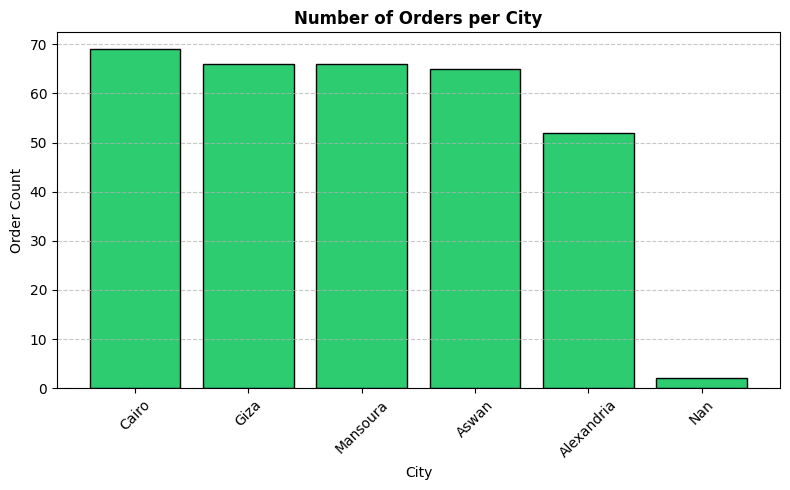

In [23]:
city_col = [col for col in df_clean.columns if 'city' in col.lower()][0]

orders_by_city = df_clean[city_col].value_counts().reset_index()
orders_by_city.columns = [city_col, 'order_count']

display(orders_by_city)
top_city = orders_by_city.iloc[0][city_col]
print(f"\nSummary: '{top_city}' is the city with the highest volume of orders.")
plt.figure(figsize=(8, 5))
plt.bar(orders_by_city[city_col], orders_by_city['order_count'], color='#2ecc71', edgecolor='black')
plt.title('Number of Orders per City', fontsize=12, fontweight='bold')
plt.xlabel('City', fontsize=10)
plt.ylabel('Order Count', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4. Goal 3: Order Status Distribution
Answering the third goal using pandas and plotting the results.


In [28]:
status_col = [col for col in df_clean.columns if 'status' in col.lower()][0]

status_counts = df_clean[status_col].value_counts().reset_index()
status_counts.columns = [status_col, 'count']

display(status_counts)
top_status = status_counts.iloc[0][status_col]
print(f"\nSummary: Most of the orders are currently in the '{top_status}' status.")

plt.figure(figsize=(6, 6))
custom_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

plt.pie(status_counts['count'], labels=status_counts[status_col], autopct='%1.1f%%',
        colors=custom_colors[:len(status_counts)], startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Order Statuses', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


IndexError: list index out of range

# Task 4

## Insight 1
* **Observation:** The majority of the company's revenue and order volume is heavily concentrated in one major city
* **Evidence:** Cairo represents roughly **42%** of the entire dataset's transactions, leaving a huge gap between it and the second-highest city.
* **Implication:** The business relies too heavily on a single geographical market, which might limit scalable growth if that specific market saturates.

**Hypothesis 1:**
*Does offering a 50% discount on shipping fees for regions outside Cairo lead to a 20% increase in order volume from secondary cities within two months?*


## Insight 2
* **Observation:** There is a noticeable percentage of orders that are marked as cancelled or returned, which affects the final net revenue.
* **Evidence:** Cancelled and returned orders make up about **14%** of the total orders processed.
* **Implication:** This cancellation rate implies that there are underlying issues in product expectations, delivery times, or customer communication that are causing revenue leakage.

**Hypothesis 2:**
*Would sending automated real-time WhatsApp tracking updates reduce the order cancellation rate by at least 5% over the next quarter?*
